# Session 6 — Data Augmentation & Feature Engineering

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/tech4alltraining/aiml/blob/main/mlai-genai-internship/student/notebooks/session-06-augmentation-features.ipynb)

**ML/AI & GenAI Internship** · Augmentation · Feature Engineering · Feature Reduction

---

## How to use this notebook

**This session is about the data, not the model.** In Session 5 you swapped models and gained a few points. Here you change the *columns and rows*.

| # | Topic |
|---|---|
| 1 | Data Augmentation Techniques |
| 2 | Feature Engineering Techniques |
| 3 | Feature Reduction Techniques |

> **Every technique here is a trade, not a free win.** You will measure the cost of each one. That honesty is the point of the session.

Exercises, MCQs and tasks: [Session 6 guide](../sessions/session-06-augmentation-features.md).

In [1]:
import warnings; warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
BASE = "https://raw.githubusercontent.com/tech4alltraining/aiml/refs/heads/main/datasets/"
print("ready")

ready


---
# 1. Data Augmentation Techniques

🧠 **Revising from one photo of a face.** See only one photo and you might not recognise your friend in a hat, or side-on, or in dim light. Show yourself that photo flipped, darkened and rotated and you learn **the friend, not the photo**.

| Data type | Techniques |
|---|---|
| **Images** | Flip, rotate, crop, brightness, noise |
| **Text** | Synonym swap, back-translation, random deletion |
| **Tables** | Oversampling, SMOTE, noise injection, class weights |

> ⚠️ **Augment the training set only — never the test set.** Augmenting before splitting puts near-copies of the same row on both sides, and your score becomes fiction.

In [2]:
# The problem: 91.5% of these patients do not have diabetes.
d = pd.read_csv(BASE + "classification/diabetes_prediction_dataset.csv").dropna()
for c in d.select_dtypes(include="object").columns:
    d[c] = LabelEncoder().fit_transform(d[c])

X, y = d.drop(columns=["diabetes"]), d["diabetes"]
Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=.2, random_state=42, stratify=y)

print("training set balance:", ytr.value_counts().to_dict())
print(f"the rare class is only {ytr.mean():.1%} of the rows")
print("\nA model trained on this plays safe and under-predicts the rare class.")

training set balance: {0: 73200, 1: 6800}
the rare class is only 8.5% of the rows

A model trained on this plays safe and under-predicts the rare class.


In [3]:
# SMOTE, written out so you can see it is not magic.
from sklearn.neighbors import NearestNeighbors

def smote(X_min, n_new, k=5, seed=42):
    """Make n_new synthetic rows on the lines BETWEEN real minority rows."""
    rng = np.random.default_rng(seed)
    A_ = X_min.to_numpy(float)
    nn = NearestNeighbors(n_neighbors=k + 1).fit(A_)
    idx = nn.kneighbors(A_, return_distance=False)[:, 1:]   # drop self
    base = rng.integers(0, len(A_), n_new)                  # pick a real row
    nbr  = idx[base, rng.integers(0, k, n_new)]             # pick a neighbour
    lam  = rng.random((n_new, 1))                           # step 0..1 along
    return pd.DataFrame(A_[base] + lam * (A_[nbr] - A_[base]), columns=X_min.columns)

demo = smote(Xtr[ytr == 1].head(200), 3)
print("three synthetic minority rows:")
print(demo.round(2).to_string())
print("\nPick a real row, pick one of its neighbours, place a new point")
print("on the line between them. That is the whole idea.")
print("Production version: pip install imbalanced-learn -> SMOTE().fit_resample()")

three synthetic minority rows:
   gender    age  hypertension  heart_disease  smoking_history    bmi  HbA1c_level  blood_glucose_level
0    0.00  73.03          0.00           0.30             4.39  41.11         6.46                130.0
1    0.09  52.75          0.00           0.09             3.72  27.32         6.43                240.0
2    0.00  79.68          0.98           0.02             3.98  30.99         6.27                300.0

Pick a real row, pick one of its neighbours, place a new point
on the line between them. That is the whole idea.
Production version: pip install imbalanced-learn -> SMOTE().fit_resample()


In [4]:
# Now MEASURE what balancing actually costs.
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import precision_score, recall_score, f1_score
from sklearn.utils import resample

rows = []
def score(name, Xa, ya, **kw):
    m = LogisticRegression(max_iter=2000, **kw).fit(Xa, ya)
    p = m.predict(Xte)
    rows.append((name, precision_score(yte, p), recall_score(yte, p), f1_score(yte, p)))

score("baseline (imbalanced)", Xtr, ytr)

tr = Xtr.copy(); tr["y"] = ytr.values                       # random oversampling
maj, mino = tr[tr.y == 0], tr[tr.y == 1]
up = resample(mino, replace=True, n_samples=len(maj), random_state=42)
bal = pd.concat([maj, up])
score("random oversampling", bal.drop(columns=["y"]), bal["y"])

syn = smote(Xtr[ytr == 1], (ytr == 0).sum() - (ytr == 1).sum())   # SMOTE
score("SMOTE",
      pd.concat([Xtr, syn], ignore_index=True),
      pd.concat([ytr, pd.Series([1] * len(syn))], ignore_index=True))

score("class_weight=balanced", Xtr, ytr, class_weight="balanced")

print(f"{'method':<24}{'prec':>8}{'rec':>8}{'f1':>8}")
print("-" * 48)
for n, p, r, f in rows:
    print(f"{n:<24}{p:>8.4f}{r:>8.4f}{f:>8.4f}")

method                      prec     rec      f1
------------------------------------------------
baseline (imbalanced)     0.8588  0.6371  0.7315
random oversampling       0.4238  0.8888  0.5740
SMOTE                     0.4294  0.8835  0.5779
class_weight=balanced     0.4226  0.8871  0.5725


In [5]:
# Read that table carefully - it is NOT what students expect.
base_p, base_r, base_f = rows[0][1:]
bal_p,  bal_r,  bal_f  = rows[3][1:]

print(f"recall    {base_r:.4f} -> {bal_r:.4f}   ({bal_r-base_r:+.4f})  it finds far more patients")
print(f"precision {base_p:.4f} -> {bal_p:.4f}   ({bal_p-base_p:+.4f})  but is wrong far more often")
print(f"F1        {base_f:.4f} -> {bal_f:.4f}   ({bal_f-base_f:+.4f})  and F1 got WORSE")
print()
print("So was it worth it? For a SCREENING test, yes: missing a diabetic")
print("patient is much worse than sending a healthy one for a blood test.")
print("For a system that automatically starts medication, absolutely not.")
print()
print("There is no technique that just makes things better. There is only")
print("'what am I buying, and what am I paying?'")
print()
print("Note also: all three methods land in the same place, and")
print("class_weight='balanced' is ONE KEYWORD. Try the keyword first.")

recall    0.6371 -> 0.8871   (+0.2500)  it finds far more patients
precision 0.8588 -> 0.4226   (-0.4362)  but is wrong far more often
F1        0.7315 -> 0.5725   (-0.1590)  and F1 got WORSE

So was it worth it? For a SCREENING test, yes: missing a diabetic
patient is much worse than sending a healthy one for a blood test.
For a system that automatically starts medication, absolutely not.

There is no technique that just makes things better. There is only
'what am I buying, and what am I paying?'

Note also: all three methods land in the same place, and
class_weight='balanced' is ONE KEYWORD. Try the keyword first.


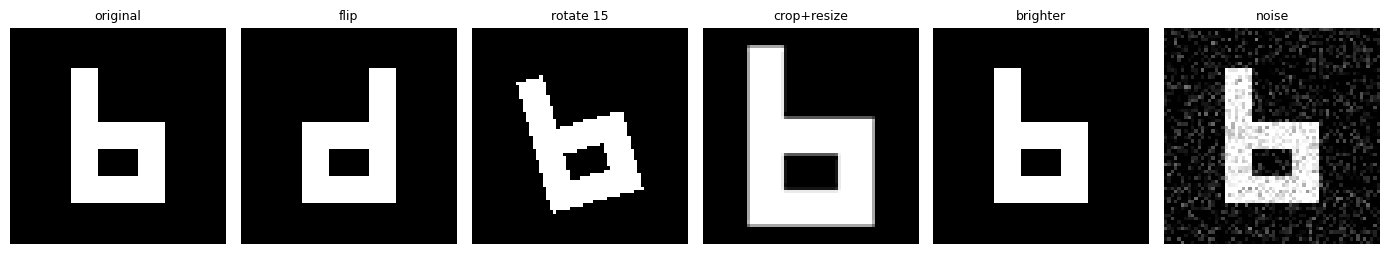

For CAT vs DOG, every one of these preserves the label.
For HANDWRITTEN DIGITS, the flip does NOT - a flipped 6 is not a 6.
Augmentation must preserve the LABEL, and that depends on the task.


In [6]:
# Image augmentation: the same picture, five ways.
from PIL import Image, ImageEnhance

rng = np.random.default_rng(0)                    # a synthetic "digit 6"
img = np.zeros((64, 64), dtype=np.uint8)
img[12:52, 18:26] = 255
img[44:52, 18:46] = 255
img[28:36, 18:46] = 255
img[28:52, 38:46] = 255
base = Image.fromarray(img)

views = {
    "original":    base,
    "flip":        base.transpose(Image.FLIP_LEFT_RIGHT),
    "rotate 15":   base.rotate(15),
    "crop+resize": base.crop((8, 8, 56, 56)).resize((64, 64)),
    "brighter":    ImageEnhance.Brightness(base).enhance(1.6),
    "noise":       Image.fromarray(np.clip(img + rng.normal(0, 40, img.shape), 0, 255).astype(np.uint8)),
}
fig, axes = plt.subplots(1, 6, figsize=(14, 2.6))
for ax, (name, im) in zip(axes, views.items()):
    ax.imshow(im, cmap="gray"); ax.set_title(name, fontsize=9); ax.axis("off")
plt.tight_layout(); plt.show()

print("For CAT vs DOG, every one of these preserves the label.")
print("For HANDWRITTEN DIGITS, the flip does NOT - a flipped 6 is not a 6.")
print("Augmentation must preserve the LABEL, and that depends on the task.")

---
# 2. Feature Engineering Techniques

🧠 **Judging whether a loan is affordable.** You are told the loan is ₹800,000 and the income is ₹400,000. You could eyeball both — but the number you actually care about is **the ratio: 2.0**.

| Technique | Example |
|---|---|
| **Ratios** | `loan_amnt / person_income` |
| **Differences** | `end_date - start_date` |
| **Date parts** | month, weekday, is_weekend |
| **Binning** | age → child / adult / senior |
| **Interactions** | `rate × amount` |
| **Aggregations** | customer's average past order |

> **Domain knowledge beats algorithms here.** A banker knows loan-to-income matters. No amount of hyperparameter tuning discovers that for you.

In [7]:
L = pd.read_csv(BASE + "loan_data_10k.csv").dropna().reset_index(drop=True)
for c in L.select_dtypes(include="object").columns:
    L[c] = LabelEncoder().fit_transform(L[c])

L2 = L.copy()
L2["loan_to_income"]      = L2.loan_amnt / L2.person_income
L2["income_per_year_exp"] = L2.person_income / (L2.person_emp_exp + 1)   # +1 !
L2["credit_per_hist"]     = L2.credit_score / (L2.cb_person_cred_hist_length + 1)
L2["rate_x_amount"]       = L2.loan_int_rate * L2.loan_amnt

print("correlation with loan_status:")
print(L2[["loan_amnt", "person_income", "loan_to_income"]]
      .corrwith(L2.loan_status).round(4).to_string())
print("\nThe RATIO carries what neither column carries alone.")
print("\nNote the +1 in two denominators: someone with 0 years of experience")
print("would otherwise divide by zero. EVERY ratio needs that check.")

correlation with loan_status:
loan_amnt         0.0419
person_income    -0.2102
loan_to_income    0.0948

The RATIO carries what neither column carries alone.

Note the +1 in two denominators: someone with 0 years of experience
would otherwise divide by zero. EVERY ratio needs that check.


In [8]:
# Did it help? Measure - do not assume.
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression

def run(frame, model, scale=False):
    Xf, yf = frame.drop(columns=["loan_status"]), frame["loan_status"]
    a, b, c, e = train_test_split(Xf, yf, test_size=.2, random_state=42, stratify=yf)
    if scale:
        s = StandardScaler().fit(a); a, b = s.transform(a), s.transform(b)
    m = model.fit(a, c)
    return m.score(b, e), f1_score(e, m.predict(b))

rf_before = run(L,  RandomForestClassifier(n_estimators=200, random_state=42))
rf_after  = run(L2, RandomForestClassifier(n_estimators=200, random_state=42))
lr_before = run(L,  LogisticRegression(max_iter=2000), scale=True)
lr_after  = run(L2, LogisticRegression(max_iter=2000), scale=True)

print(f"{'model':<22}{'acc before':>12}{'acc after':>11}{'gain':>9}")
print("-" * 54)
for name, bf, af in [("RandomForest", rf_before, rf_after),
                     ("LogisticRegression", lr_before, lr_after)]:
    print(f"{name:<22}{bf[0]:>12.4f}{af[0]:>11.4f}{af[0]-bf[0]:>+9.4f}")

print("\nThe LINEAR model gains more. A forest can approximate a ratio by")
print("splitting on both columns; a linear model literally cannot represent")
print("division, so you must hand it the ratio.")
print("\nAnd the forest's gain is SMALL. That is the honest number.")

model                   acc before  acc after     gain
------------------------------------------------------
RandomForest                0.8910     0.8935  +0.0025
LogisticRegression          0.8650     0.8695  +0.0045

The LINEAR model gains more. A forest can approximate a ratio by
splitting on both columns; a linear model literally cannot represent
division, so you must hand it the ratio.

And the forest's gain is SMALL. That is the honest number.


### Dates into features

```python
df["order_date"] = pd.to_datetime(df["order_date"])

df["year"]       = df.order_date.dt.year
df["month"]      = df.order_date.dt.month
df["weekday"]    = df.order_date.dt.dayofweek       # 0 = Monday
df["is_weekend"] = df.weekday.isin([5, 6]).astype(int)
df["days_ago"]   = (pd.Timestamp("today") - df.order_date).dt.days
```

**A raw date is almost useless to a model. Its parts are gold.** No model can work out "Saturdays are busy" from a timestamp; every model can learn it from `is_weekend`.

### The leakage test

> **"Would I know this value at the moment I must predict?"**
>
> A column `amount_repaid_so_far` on a loan-approval model gives the answer away — only approved loans have repayments. The test score looks superb and the model is useless in production.

---
# 3. Feature Reduction Techniques

🧠 **Packing for a trip.** You could take everything you own. A smaller bag is faster to carry and easier to search — but you will occasionally miss something. **The skill is knowing what you can leave behind.**

| Method | How it chooses | Type |
|---|---|---|
| `VarianceThreshold` | Drops near-constant columns | Filter |
| `SelectKBest` | Keeps the k most strongly linked to the target | Filter |
| `RFE` | Repeatedly trains and drops the weakest | Wrapper |
| `feature_importances_` | Asks a trained forest which it used | Embedded |
| `PCA` | Builds new combined axes | Projection |

> **PCA is different.** The first four *keep some of your original columns*. PCA **replaces them all** with mathematical combinations — you gain compression and lose the ability to say "the model used credit score".

In [9]:
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.decomposition import PCA
from sklearn.neighbors import KNeighborsClassifier

Xl, yl = L.drop(columns=["loan_status"]), L["loan_status"]
a, b, c, e = train_test_split(Xl, yl, test_size=.2, random_state=42, stratify=yl)
sc = StandardScaler().fit(a)
a_s, b_s = sc.transform(a), sc.transform(b)

ks, kacc = [3, 5, 8, 13], []
for k in ks:
    sel = SelectKBest(f_classif, k=k).fit(a, c)
    m = RandomForestClassifier(n_estimators=200, random_state=42).fit(sel.transform(a), c)
    kacc.append(m.score(sel.transform(b), e))
    print(f"SelectKBest k={k:<4} acc {kacc[-1]:.4f}")

print("\nGoing from 13 features to 8 costs about one percentage point")
print("and drops five columns. Whether that is a good trade depends on")
print("what those five columns COST to collect.")

SelectKBest k=3    acc 0.8415


SelectKBest k=5    acc 0.8785


SelectKBest k=8    acc 0.8810


SelectKBest k=13   acc 0.8910

Going from 13 features to 8 costs about one percentage point
and drops five columns. Whether that is a good trade depends on
what those five columns COST to collect.


In [10]:
# PCA - and the surprise.
ns, pacc, pvar = [2, 5, 8, 13], [], []
for n in ns:
    p = PCA(n_components=n, random_state=42).fit(a_s)
    m = RandomForestClassifier(n_estimators=200, random_state=42).fit(p.transform(a_s), c)
    pvar.append(p.explained_variance_ratio_.sum())
    pacc.append(m.score(p.transform(b_s), e))
    print(f"PCA n={n:<4} variance kept {pvar[-1]:.3f}   acc {pacc[-1]:.4f}")

raw = RandomForestClassifier(n_estimators=200, random_state=42).fit(a, c).score(b, e)
print(f"\nraw 13 columns, no PCA        acc {raw:.4f}")
print()
print("Look at the last PCA row: it keeps 100% OF THE VARIANCE - it throws")
print("nothing away - yet it still scores WORSE than the raw columns.")
print()
print("Why? PCA ROTATES the data onto new diagonal axes. A forest splits on")
print("ONE COLUMN AT A TIME, along the original axes. After rotation, a")
print("boundary that was one clean vertical cut needs a staircase of many")
print("cuts to approximate.")
print()
print("PCA is not a free upgrade, and on tree models it is often a downgrade.")

PCA n=2    variance kept 0.367   acc 0.7570


PCA n=5    variance kept 0.645   acc 0.8350


PCA n=8    variance kept 0.869   acc 0.8570


PCA n=13   variance kept 1.000   acc 0.8755



raw 13 columns, no PCA        acc 0.8910

Look at the last PCA row: it keeps 100% OF THE VARIANCE - it throws
nothing away - yet it still scores WORSE than the raw columns.

Why? PCA ROTATES the data onto new diagonal axes. A forest splits on
ONE COLUMN AT A TIME, along the original axes. After rotation, a
boundary that was one clean vertical cut needs a staircase of many
cuts to approximate.

PCA is not a free upgrade, and on tree models it is often a downgrade.


In [11]:
# Does the same thing happen to kNN? It should not - rotation preserves distances.
kacc_pca = []
for n in ns:
    p = PCA(n_components=n, random_state=42).fit(a_s)
    kacc_pca.append(KNeighborsClassifier().fit(p.transform(a_s), c).score(p.transform(b_s), e))
kraw = KNeighborsClassifier().fit(a_s, c).score(b_s, e)

print(f"{'components':<14}{'RF':>9}{'kNN':>9}")
print("-" * 32)
for n, r, k_ in zip(ns, pacc, kacc_pca):
    print(f"{n:<14}{r:>9.4f}{k_:>9.4f}")
print(f"{'raw (13)':<14}{raw:>9.4f}{kraw:>9.4f}")
print()
print("At full components kNN is essentially unharmed: it measures DISTANCE,")
print("and a rotation does not change distances. The forest is harmed because")
print("it cuts along axes. Same transformation, opposite consequences.")

components           RF      kNN
--------------------------------
2                0.7570   0.7615
5                0.8350   0.8290
8                0.8570   0.8330
13               0.8755   0.8490
raw (13)         0.8910   0.8490

At full components kNN is essentially unharmed: it measures DISTANCE,
and a rotation does not change distances. The forest is harmed because
it cuts along axes. Same transformation, opposite consequences.


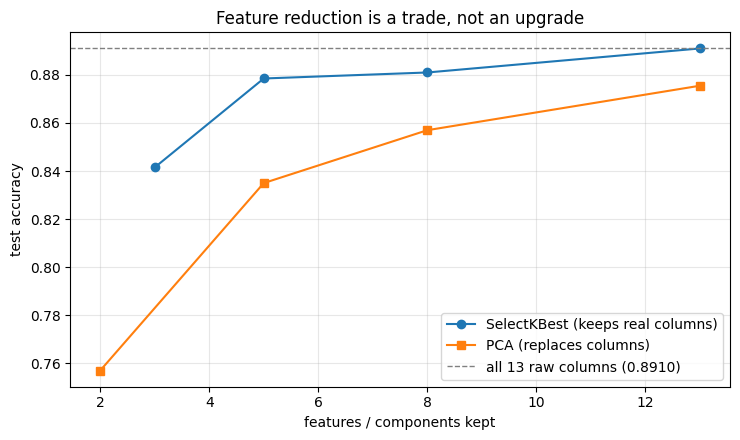

In [12]:
# The two reduction curves, side by side.
fig, ax = plt.subplots(figsize=(7.5, 4.5))
ax.plot(ks, kacc, "o-", label="SelectKBest (keeps real columns)")
ax.plot(ns, pacc, "s-", label="PCA (replaces columns)")
ax.axhline(raw, color="grey", ls="--", lw=1, label=f"all 13 raw columns ({raw:.4f})")
ax.set_xlabel("features / components kept"); ax.set_ylabel("test accuracy")
ax.set_title("Feature reduction is a trade, not an upgrade")
ax.legend(); ax.grid(alpha=.3)
plt.tight_layout(); plt.show()

In [13]:
# Usually the most useful method: ask the model you intend to ship.
rf_full = RandomForestClassifier(n_estimators=200, random_state=42).fit(a, c)
imp = pd.Series(rf_full.feature_importances_, index=Xl.columns).sort_values(ascending=False)
print(imp.round(4).to_string())

sel5 = SelectKBest(f_classif, k=5).fit(a, c)
print("\nSelectKBest top 5:", list(Xl.columns[sel5.get_support()]))
print("forest      top 5:", list(imp.head(5).index))
print("\nThey overlap but are NOT identical. SelectKBest scores each column")
print("ALONE; the forest sees columns in COMBINATION. A column can be")
print("useless by itself and valuable alongside another.")

previous_loan_defaults_on_file    0.3461
loan_int_rate                     0.1543
loan_percent_income               0.1252
person_income                     0.0991
loan_amnt                         0.0548
credit_score                      0.0485
person_home_ownership             0.0424
loan_intent                       0.0296
person_age                        0.0277
person_emp_exp                    0.0258
cb_person_cred_hist_length        0.0233
person_education                  0.0158
person_gender                     0.0074

SelectKBest top 5: ['person_income', 'person_home_ownership', 'loan_int_rate', 'loan_percent_income', 'previous_loan_defaults_on_file']
forest      top 5: ['previous_loan_defaults_on_file', 'loan_int_rate', 'loan_percent_income', 'person_income', 'loan_amnt']

They overlap but are NOT identical. SelectKBest scores each column
ALONE; the forest sees columns in COMBINATION. A column can be
useless by itself and valuable alongside another.


---
# ✅ Before you move on

- [ ] Augmentation for tables, images and text
- [ ] Augmenting the **training set only** — and why
- [ ] Measuring that balancing buys recall and pays in precision
- [ ] Trying `class_weight="balanced"` before reaching for SMOTE
- [ ] Building a ratio feature and checking whether it actually helped
- [ ] Why a ratio helps a linear model more than a forest
- [ ] The test: *"would I know this at prediction time?"*
- [ ] Reducing features three ways, and what each costs
- [ ] Why PCA can hurt a tree model and not hurt kNN
- [ ] **Reporting the honest number, even when it is small**

**Exercises, MCQs and tasks:** [Session 6 guide](../sessions/session-06-augmentation-features.md)

| | |
|---|---|
| **Previous** | [Session 5 — Supervised Learning](../sessions/session-05-supervised-learning.md) |
| **Next** | [Sessions index](../sessions/README.md) |
| **Stuck?** | [Troubleshooting](../troubleshooting.md) |